## Section 1: Setup & Environment

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import cv2
from transformers import Sam2VideoModel, Sam2VideoProcessor

# Environment check
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# OpenCV version (for video I/O)
print(f"OpenCV: {cv2.__version__}")

# VRAM control — initial state
if torch.cuda.is_available():
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"VRAM in use: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

/home/cagan/open-vocab-perception/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu130
CUDA available: True
Device: NVIDIA GeForce RTX 3050 Ti Laptop GPU
OpenCV: 4.11.0
VRAM total: 3.68 GB
VRAM in use: 0.0 MB


## Section 2: Test Video Preparation

In [2]:
video_path = str(Path("../data/demo_inputs/people_walking.mp4").resolve())
frames_dir = Path("../data/demo_frames/people_walking").resolve()
frames_dir.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

for i in range(total):
    ret, frame = cap.read()
    if not ret:
        break
    # Convert the frame from BGR to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    cv2.imwrite(str(frames_dir / f"{i:05d}.jpg"), frame)  # save as .jpg, with BGR

print(f"Saved {total} frames to {frames_dir}, fps={fps}")

Saved 279 frames to /home/cagan/open-vocab-perception/data/demo_frames/people_walking, fps=29.97002997002997


## Section 3: Model Loading & VRAM Profile

In [3]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

mem_before = torch.cuda.memory_allocated() / 1024**2

MODEL_ID = "facebook/sam2.1-hiera-tiny"
DEVICE = "cuda"

print("Loading processor...")
processor = Sam2VideoProcessor.from_pretrained(MODEL_ID)

print("Loading model...")
model = Sam2VideoModel.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

mem_after = torch.cuda.memory_allocated() / 1024**2
print(f"\nVRAM used by model: {mem_after - mem_before:.1f} MB")
print(f"Total VRAM allocated: {mem_after:.1f} MB")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading processor...
Loading model...

VRAM used by model: 157.8 MB
Total VRAM allocated: 157.8 MB
Model parameters: 39.0M


## Section 4: First Video Inference

Frame 0 shape: (1280, 720, 3)


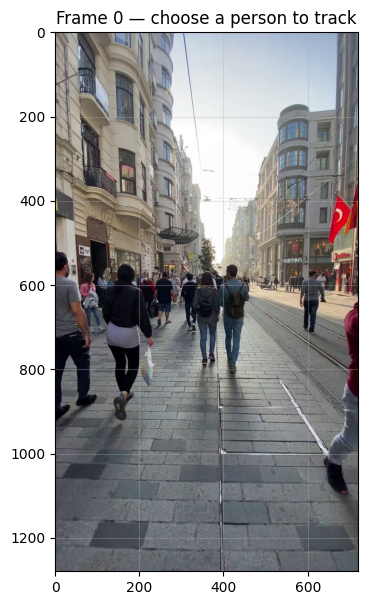

In [4]:
# Load frame 0 and show it
frame_0_path = frames_dir / "00000.jpg"
frame_0 = cv2.imread(str(frame_0_path))
frame_0_rgb = cv2.cvtColor(frame_0, cv2.COLOR_BGR2RGB)

print(f"Frame 0 shape: {frame_0_rgb.shape}")  # (H, W, 3)

plt.figure(figsize=(12, 7))
plt.imshow(frame_0_rgb)
plt.title("Frame 0 — choose a person to track")
plt.axis("on")  # 'on' for visualizing coordinate system also for bbox
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Load frames as PIL image list
print("Loading frames as PIL list...")
frame_paths = sorted(frames_dir.glob("*.jpg"))
N_FRAMES = 60
TARGET_SIZE = (640, 360)  # half resolution to not overwhelm the RAM

frame_paths = sorted(frames_dir.glob("*.jpg"))[:N_FRAMES]
video_frames_pil = [
    Image.open(p).convert("RGB").resize(TARGET_SIZE, Image.BILINEAR)
    for p in frame_paths
]
print(f"Loaded {len(video_frames_pil)} frames")

# Inference session initialization
print("\nInitializing video session...")
inference_session = processor.init_video_session(
    video=video_frames_pil,
    inference_device=DEVICE,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.float32,
)

print(f"Session initialized.")
print(f"Video shape: {inference_session.video_height}x{inference_session.video_width}")
print(f"VRAM after init: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

Loading frames as PIL list...
Loaded 60 frames

Initializing video session...
Session initialized.
Video shape: 360x640
VRAM after init: 157.8 MB


In [6]:
# Resized to 640x360, scale factor = 0.5; Basically we devide by 2
target_bbox = [140, 155, 240, 270]
ann_frame_idx = 0
ann_obj_id = 1

processor.add_inputs_to_inference_session(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_boxes=[[target_bbox]],
)

outputs = model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)

video_res_masks = processor.post_process_masks(
    [outputs.pred_masks],
    original_sizes=[[inference_session.video_height, inference_session.video_width]],
    binarize=True,
)[0]

print(f"Mask shape: {video_res_masks.shape}")
print(f"VRAM after first inference: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

Mask shape: torch.Size([1, 1, 360, 640])
VRAM after first inference: 268.9 MB


In [7]:
# Sanity check — frame size
print(f"First PIL frame size (W, H): {video_frames_pil[0].size}")
# expected: (640, 360)

# Bbox control
print(f"Bbox: {target_bbox}")
print(f"Bbox in frame? x: 0-{video_frames_pil[0].size[0]}, y: 0-{video_frames_pil[0].size[1]}")

First PIL frame size (W, H): (640, 360)
Bbox: [140, 155, 240, 270]
Bbox in frame? x: 0-640, y: 0-360


Mask shape: (360, 640), sum (pixels): 3593


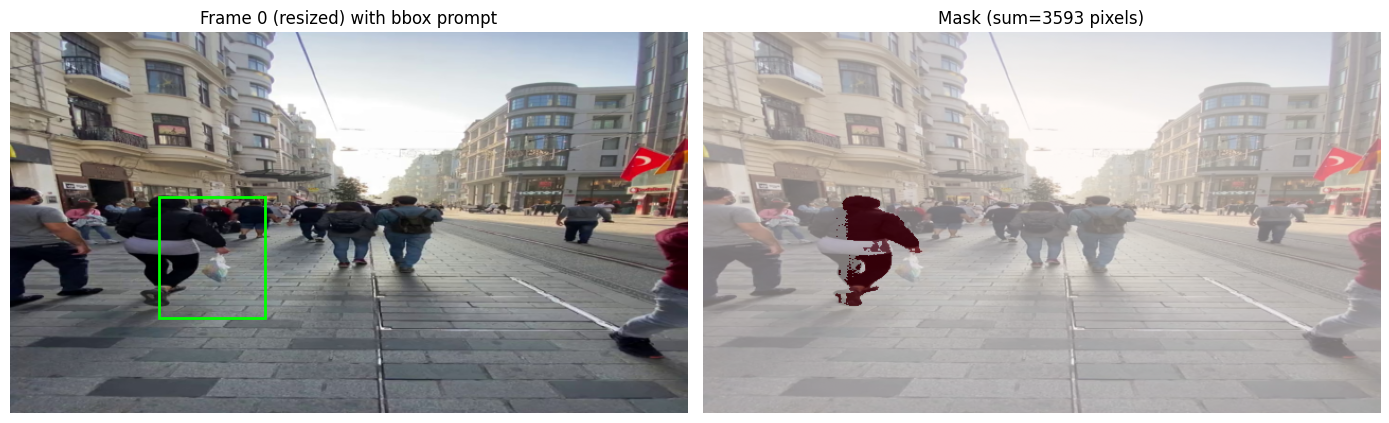

In [8]:
# Mask -> binary numpy
mask_frame0 = video_res_masks[0, 0].cpu().numpy()  # şekil: (H, W)
print(f"Mask shape: {mask_frame0.shape}, sum (pixels): {mask_frame0.sum()}")

# Visualize
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Show resized frame (bbox prompt in right frame)
frame_pil = video_frames_pil[0]
frame_np = np.array(frame_pil)

axes[0].imshow(frame_np)
x1, y1, x2, y2 = target_bbox
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, edgecolor='lime', linewidth=2, facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title(f"Frame 0 (resized) with bbox prompt")
axes[0].axis("off")

# Mask overlay
axes[1].imshow(frame_np)
axes[1].imshow(mask_frame0, alpha=0.5, cmap='Reds')
axes[1].set_title(f"Mask (sum={mask_frame0.sum()} pixels)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Section 5: Mask Propagation Through Video

In [9]:
# Propagate trough entire video
video_segments = {}

print("Propagating through video...")
for sam2_video_output in model.propagate_in_video_iterator(inference_session):
    frame_idx = sam2_video_output.frame_idx
    
    # Convert mask to original size
    masks_for_frame = processor.post_process_masks(
        [sam2_video_output.pred_masks],
        original_sizes=[[inference_session.video_height, inference_session.video_width]],
        binarize=True,
    )[0]
    
    # Save mask for frame (binary numpy)
    video_segments[frame_idx] = masks_for_frame[0, 0].cpu().numpy()

print(f"Propagated through {len(video_segments)} frames")
print(f"VRAM after propagation: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

Propagating through video...


propagate in video: 100%|██████████| 60/60 [00:27<00:00,  2.15it/s]

Propagated through 60 frames
VRAM after propagation: 314.5 MB


## Section 6: Video Visualization

In [10]:
output_video_path = Path("../outputs/sam2_video_demo.mp4").resolve()
output_video_path.parent.mkdir(parents=True, exist_ok=True)

# Take the sizes within first frame
H, W = video_frames_pil[0].size[1], video_frames_pil[0].size[0]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(output_video_path), fourcc, 30, (W, H))

for frame_idx in sorted(video_segments.keys()):
    # PIL frame -> numpy
    frame_np = np.array(video_frames_pil[frame_idx])  # RGB
    
    # Mask
    mask = video_segments[frame_idx].astype(bool)
    
    # Overlay (red tint masked area)
    overlay = frame_np.copy()
    overlay[mask] = (overlay[mask] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)
    
    # OpenCV wants BGR format
    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    writer.write(overlay_bgr)

writer.release()
print(f"Saved video to {output_video_path}")

Saved video to /home/cagan/open-vocab-perception/outputs/sam2_video_demo.mp4


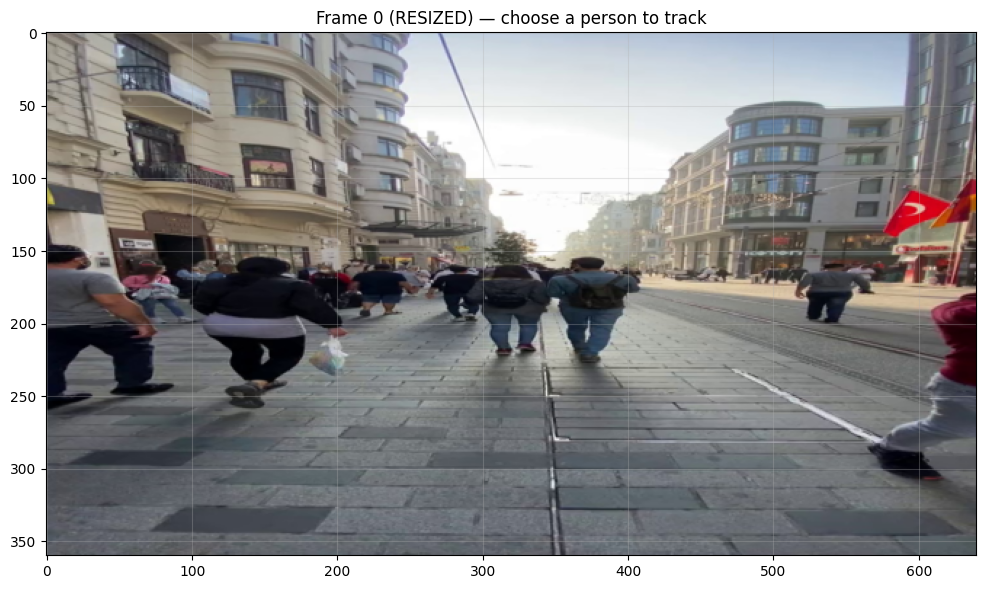

In [11]:
plt.figure(figsize=(12, 7))
plt.imshow(np.array(video_frames_pil[0]))
plt.title("Frame 0 (RESIZED) — choose a person to track")
plt.axis("on")
plt.grid(True, alpha=0.3)
plt.show()

Frame-by-frame mask sum check:
Frame   0: dtype=bool, shape=(360, 640), sum=3593, min=False, max=True
Frame   5: dtype=bool, shape=(360, 640), sum=3312, min=False, max=True
Frame  10: dtype=bool, shape=(360, 640), sum=4699, min=False, max=True
Frame  15: dtype=bool, shape=(360, 640), sum=3402, min=False, max=True
Frame  20: dtype=bool, shape=(360, 640), sum=3749, min=False, max=True
Frame  25: dtype=bool, shape=(360, 640), sum=3361, min=False, max=True
Frame  30: dtype=bool, shape=(360, 640), sum=3437, min=False, max=True
Frame  35: dtype=bool, shape=(360, 640), sum=3192, min=False, max=True
Frame  40: dtype=bool, shape=(360, 640), sum=5016, min=False, max=True
Frame  45: dtype=bool, shape=(360, 640), sum=3993, min=False, max=True
Frame  50: dtype=bool, shape=(360, 640), sum=3719, min=False, max=True
Frame  55: dtype=bool, shape=(360, 640), sum=3185, min=False, max=True


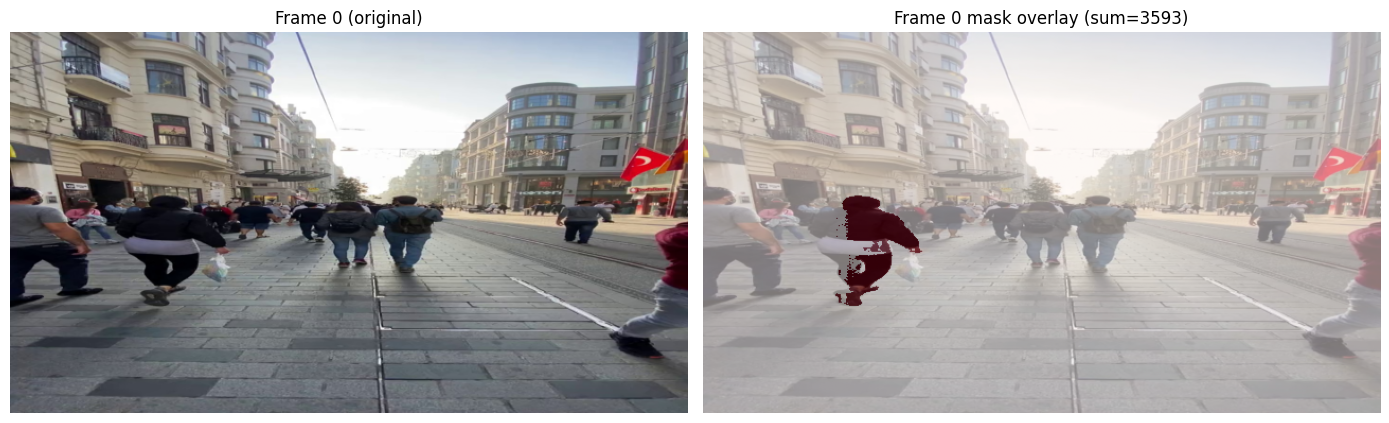

In [12]:
print("Frame-by-frame mask sum check:")
print("="*40)
for frame_idx in sorted(video_segments.keys())[::5]:  # in every 5 frame
    mask = video_segments[frame_idx]
    print(f"Frame {frame_idx:3d}: dtype={mask.dtype}, "
          f"shape={mask.shape}, "
          f"sum={mask.sum()}, "
          f"min={mask.min()}, max={mask.max()}")

# Visualize frame 0 mask (after propagation)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

frame_np_0 = np.array(video_frames_pil[0])
axes[0].imshow(frame_np_0)
axes[0].set_title("Frame 0 (original)")
axes[0].axis("off")

axes[1].imshow(frame_np_0)
axes[1].imshow(video_segments[0], alpha=0.5, cmap='Reds')
axes[1].set_title(f"Frame 0 mask overlay (sum={video_segments[0].sum()})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Section 7: Multi Object Tracking & Propagation

In [ ]:
# Reset for new session
print("Initializing fresh multi-object session...")
inference_session = processor.init_video_session(
    video=video_frames_pil,
    inference_device=DEVICE,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.float32,
)

# 2 bbox for 2 people in frame 0
ann_frame_idx = 0
obj_ids = [1, 2]                           # 2 seperate track ID
input_boxes = [[
    [140, 155, 240, 270],                  # person 1 (left-mid, the person we chose)
    [320, 155, 420, 270],                  # person 2 (mid-center, with backpack)
]]

processor.add_inputs_to_inference_session(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=obj_ids,
    input_boxes=input_boxes,
)

Initializing fresh multi-object session...


In [14]:
# Add 2 bboxes
processor.add_inputs_to_inference_session(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=obj_ids,
    input_boxes=input_boxes,
)

# Create conditioning frame
print("Initializing conditioning frame (frame 0)...")
_ = model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
print("Conditioning frame ready, starting propagation...")

# Now propagation can start
multi_video_segments = {}
for sam2_video_output in model.propagate_in_video_iterator(inference_session):
    frame_idx = sam2_video_output.frame_idx
    
    masks_for_frame = processor.post_process_masks(
        [sam2_video_output.pred_masks],
        original_sizes=[[inference_session.video_height, inference_session.video_width]],
        binarize=True,
    )[0]
    
    multi_video_segments[frame_idx] = {
        obj_id: masks_for_frame[i, 0].cpu().numpy()
        for i, obj_id in enumerate(inference_session.obj_ids)
    }

print(f"Propagated {len(inference_session.obj_ids)} objects through {len(multi_video_segments)} frames")

Initializing conditioning frame (frame 0)...
Conditioning frame ready, starting propagation...


propagate in video:   0%|          | 0/60 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 60/60 [00:47<00:00,  1.27it/s]

Propagated 2 objects through 60 frames


In [15]:
output_video_path_multi = Path("../outputs/sam2_video_multi_demo.mp4").resolve()
H, W = video_frames_pil[0].size[1], video_frames_pil[0].size[0]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(output_video_path_multi), fourcc, 30, (W, H))

# For every obj_id, seperate color (in BGR)
COLORS = {
    1: np.array([0, 0, 255]),      # red
    2: np.array([0, 255, 0]),      # green
}

for frame_idx in sorted(multi_video_segments.keys()):
    frame_np = np.array(video_frames_pil[frame_idx])  # RGB
    overlay = frame_np.copy()
    
    for obj_id, mask in multi_video_segments[frame_idx].items():
        mask_bool = mask.astype(bool)
        color = COLORS[obj_id]
        overlay[mask_bool] = (overlay[mask_bool] * 0.5 + color * 0.5).astype(np.uint8)
    
    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    writer.write(overlay_bgr)

writer.release()
print(f"Saved multi-object video to {output_video_path_multi}")

Saved multi-object video to /home/cagan/open-vocab-perception/outputs/sam2_video_multi_demo.mp4


## Section 8: Latency Benchmark

In [16]:
import time

# Measure single frame forward latency
inference_session_bench = processor.init_video_session(
    video=video_frames_pil,
    inference_device=DEVICE,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.float32,
)

processor.add_inputs_to_inference_session(
    inference_session=inference_session_bench,
    frame_idx=0,
    obj_ids=1,
    input_boxes=[[[140, 155, 240, 270]]],
)

# Frame 0 init (first forward, image encoder included — expensive)
torch.cuda.synchronize()
t0 = time.perf_counter()
_ = model(inference_session=inference_session_bench, frame_idx=0)
torch.cuda.synchronize()
t_first_frame = (time.perf_counter() - t0) * 1000

# Iterate with propagation for later frames
torch.cuda.synchronize()
t0 = time.perf_counter()
frame_count = 0
for sam2_video_output in model.propagate_in_video_iterator(inference_session_bench):
    if sam2_video_output.frame_idx == 0:
        continue
    frame_count += 1
torch.cuda.synchronize()
t_propagation = (time.perf_counter() - t0) * 1000

per_frame_avg = t_propagation / frame_count if frame_count > 0 else 0

print(f"First frame (init + encoding + decoding): {t_first_frame:.1f} ms")
print(f"Propagation total ({frame_count} frames): {t_propagation:.1f} ms")
print(f"Per-frame average (propagation only): {per_frame_avg:.1f} ms")
print(f"Approx FPS for video tracking: {1000/per_frame_avg:.1f}" if per_frame_avg > 0 else "N/A")

propagate in video: 100%|██████████| 60/60 [00:27<00:00,  2.18it/s]


First frame (init + encoding + decoding): 167.9 ms
Propagation total (59 frames): 27819.2 ms
Per-frame average (propagation only): 471.5 ms
Approx FPS for video tracking: 2.1


### Observations & Pipeline Implications

**Test setup:** SAM 2.1 Hiera-tiny Video predictor on RTX 3050 Ti, fp32.
Test video: İstiklal Caddesi pedestrian scene, 60 frames at 640×360 resolution
(downsampled from 720×1280 to fit memory budget). CPU offloading enabled
(`processing_device="cpu"`, `video_storage_device="cpu"`) for VRAM safety.

**Mask propagation behavior:**
- Single-object tracking with bbox prompt: model successfully propagated through 
  all 60 frames with mask area stable around 3000-5000 pixels.
- Memory bank maintains object identity even as the person walks away from camera.
- However, single-object mask coverage was partial — the bbox prompt produced a 
  mask covering only the upper body and backpack rather than the full silhouette.
- Interestingly, multi-object tracking (Section 7) produced full-body masks for
  both tracked objects. SAM 2's multi-mask output selection appears to be more
  decisive when multiple prompts disambiguate the scene.

**Multi-object tracking:**
- Two bboxes on frame 0 → two distinct full-body masks propagated through all 60 frames.
- Track IDs preserved correctly throughout — no identity swap despite multiple 
  pedestrians in the scene.
- Each object segmented independently; no cross-talk between tracked instances 
  even when nearby pedestrians wore similar clothing.

**Latency findings (RTX 3050 Ti, fp32, CPU offloading):**
- First frame (prompt-conditioned forward): 167.9 ms
- Per-frame propagation average: 471.5 ms
- Approximate FPS during propagation: 2.1
- Compared to sandbox 02's image predictor (~150 ms/frame): video predictor is 
  surprisingly ~3x SLOWER per frame in this configuration. The performance 
  penalty comes from CPU↔GPU transfers required by offloading. With full GPU 
  residency, video predictor should match or exceed image predictor speed.

**Pipeline implications:**

1. **Real-time is not feasible at this configuration.** With CPU offloading,
   propagation runs at 2.1 FPS — well below real-time thresholds. Production 
   VideoPipeline must either (a) fit video on GPU when memory permits, 
   (b) process video in chunks of ~30 frames, or (c) accept offline processing.

2. **Mask quality is prompt-dependent.** Single-bbox produced partial masks; 
   multi-prompt disambiguated scenes produced complete masks. Production 
   pipeline should prefer multi-prompt scenarios or use point+bbox combined 
   prompts for tighter mask coverage.

3. **Memory bank cost.** 60-frame video at 640×360 with CPU offloading consumed
   manageable VRAM, but propagation cost grows with video length. Long videos
   may require periodic memory bank pruning or chunked processing.

4. **Revised VideoPipeline architecture.** Video predictor's true value is 
   identity-consistent mask propagation, not raw speed. Therefore:
   - GroundingDINO runs on sparse keyframes (every 10-30 frames)
   - SAM 2 Image predictor produces fresh masks on each keyframe  
   - SAM 2 Video predictor propagates masks between keyframes for ID consistency
   - ByteTracker handles cheap bbox-level tracking every frame for new object 
     discovery and basic re-identification
   - This three-component approach balances accuracy, identity, and cost.